In [8]:
import os
import yaml
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np


def get_label_distribution_nested(labels_root_dir, data_yaml_path):
    """
    Analyzes the distribution of labels in a YOLO dataset with a nested structure.

    Args:
        labels_root_dir (str): The directory that contains all the subfolders with .txt label files.
                               e.g., 'C:/Train/training_image/' if 'bf7caa3f-d063-55dd-b583-81f883eed7ef/'
                               is directly inside it.
        data_yaml_path (str): The full path to your data.yaml file.

    Returns:
        dict: A dictionary where keys are class names and values are their counts.
    """
    if not os.path.exists(labels_root_dir):
        print(f"Error: Labels root directory not found at {labels_root_dir}")
        return None
    if not os.path.exists(data_yaml_path):
        print(f"Error: data.yaml not found at {data_yaml_path}")
        return None

    # Load class names from data.yaml
    with open(data_yaml_path, "r") as f:
        data = yaml.safe_load(f)

    class_names = data.get("names")
    if not class_names:
        print(
            "Error: 'names' field not found in data.yaml. Cannot map class IDs to names."
        )
        return None

    all_class_ids = []

    # Walk through the labels_root_dir and its subdirectories
    for dirpath, dirnames, filenames in os.walk(labels_root_dir):
        # print(f"Searching in: {dirpath}") # Optional: uncomment for debugging paths
        for filename in filenames:
            if filename.endswith(".txt"):
                file_path = os.path.join(dirpath, filename)
                # print(f"Found label file: {file_path}") # Optional: uncomment for debugging found files
                with open(file_path, "r") as f:
                    for line in f:
                        parts = line.strip().split()
                        if parts:
                            try:
                                class_id = int(parts[0])
                                all_class_ids.append(class_id)
                            except ValueError:
                                print(
                                    f"Warning: Invalid class_id '{parts[0]}' in {file_path}. Skipping line."
                                )
                                continue
                            except IndexError:
                                print(
                                    f"Warning: Empty line or malformed line in {file_path}. Skipping line."
                                )
                                continue

    # Count occurrences of each class ID
    class_id_counts = Counter(all_class_ids)

    # Map class IDs to names
    label_distribution = {}
    for class_id, count in class_id_counts.items():
        if 0 <= class_id < len(class_names):
            label_distribution[class_names[class_id]] = count
        else:
            print(
                f"Warning: Class ID {class_id} found in labels but not in data.yaml names. Assigning to 'Unknown_Class_{class_id}'."
            )
            label_distribution[f"Unknown_Class_{class_id}"] = count

    return label_distribution


def plot_distribution(label_distribution, title="Label Distribution in YOLO Dataset"):
    """
    Plots the label distribution as a bar chart.
    """
    if not label_distribution:
        print("No labels to plot.")
        return

    labels = list(label_distribution.keys())
    counts = list(label_distribution.values())

    # Sort by count for better visualization
    sorted_indices = np.argsort(counts)[::-1]  # Descending order
    labels = [labels[i] for i in sorted_indices]
    counts = [counts[i] for i in sorted_indices]

    plt.figure(figsize=(12, 7))
    plt.bar(labels, counts, color="skyblue")
    plt.xlabel("Object Class")
    plt.ylabel("Number of Instances")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")  # Rotate labels for readability
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

KeyboardInterrupt: 

### Distribution for Training Set 1

Attempting to analyze labels in: training_set_1\labels\Train\training_image
Using data.yaml from: training_set_1\data.yaml

Label Distribution:
- Light Goods Vehicle: 3044
- Single-Unit Truck: 152
- Car: 10137
- Pedestrians: 600


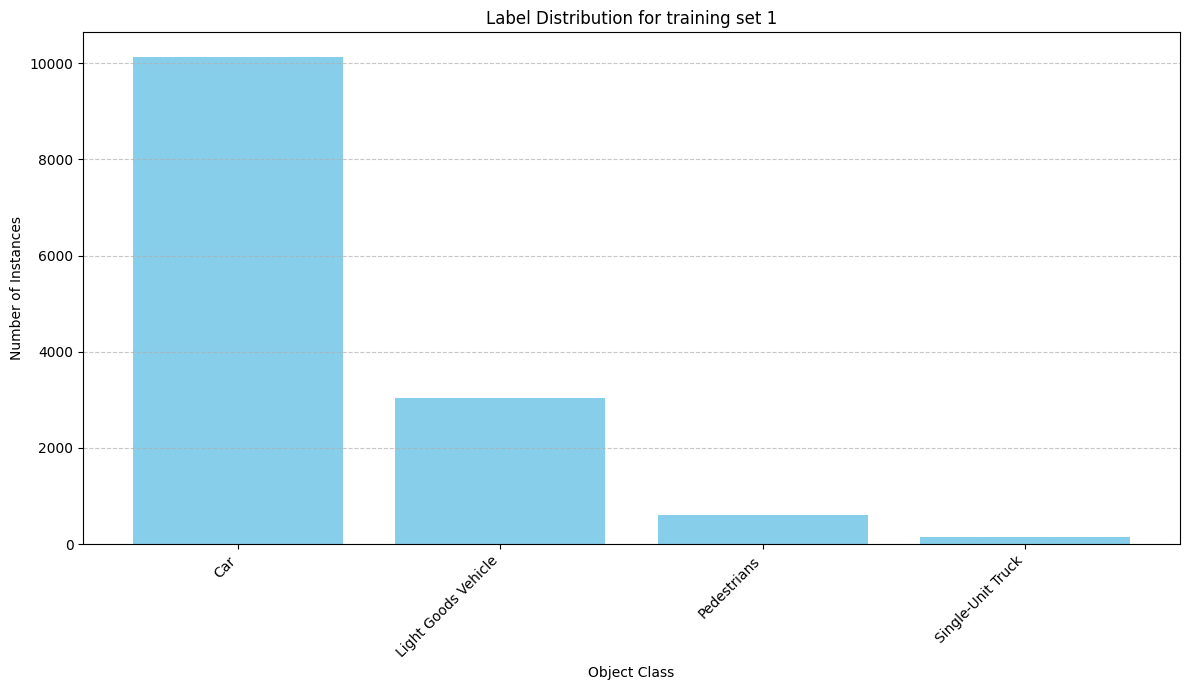

In [ ]:
# This should be the directory that *contains* folders like 'bf7caa3f-d063-55dd-b583-81f883eed7ef'
labels_root_directory = r"training_set_1\labels\Train\training_image"

# You need to locate your data.yaml file.
data_yaml_file_path = r"training_set_1\data.yaml"


print(f"Attempting to analyze labels in: {labels_root_directory}")
print(f"Using data.yaml from: {data_yaml_file_path}")

distribution = get_label_distribution_nested(labels_root_directory, data_yaml_file_path)

if distribution:
    print("\nLabel Distribution:")
    for label, count in distribution.items():
        print(f"- {label}: {count}")

    plot_distribution(distribution, title="Label Distribution for training set 1")
else:
    print("Could not determine label distribution.")

### Distribution for Training Set 2

Attempting to analyze labels in: training_set_2\labels\Train\training_image
Using data.yaml from: training_set_2\data.yaml

Label Distribution:
- Car: 2755
- Light Goods Vehicle: 97
- Single-Unit Truck: 84


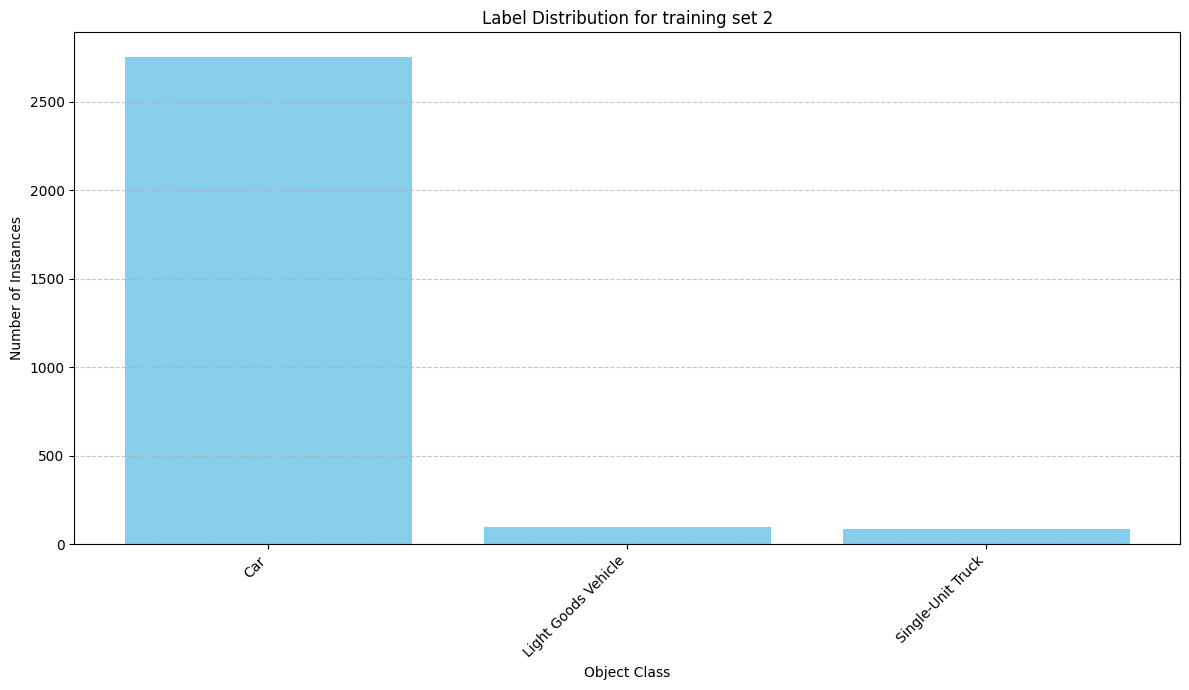

In [ ]:
# This should be the directory that *contains* folders like 'bf7caa3f-d063-55dd-b583-81f883eed7ef'
# which in turn contain the .txt label files.
# Corrected path based on your input:
labels_root_directory = r"training_set_2\labels\Train\training_image"

# You need to locate your data.yaml file.
# It's typically at the top level of the CVAT download.
data_yaml_file_path = r"training_set_2\data.yaml"


print(f"Attempting to analyze labels in: {labels_root_directory}")
print(f"Using data.yaml from: {data_yaml_file_path}")

distribution = get_label_distribution_nested(labels_root_directory, data_yaml_file_path)

if distribution:
    print("\nLabel Distribution:")
    for label, count in distribution.items():
        print(f"- {label}: {count}")

    plot_distribution(distribution, title="Label Distribution for training set 2")
else:
    print("Could not determine label distribution.")


✅ Found data.yaml at: yolo_dataset\2025-10-07_len_14200\data.yaml

--- YOLO Dataset Analyzer ---
Dataset Root: 2025-10-07_len_14200
Number of Classes (nc): 9
Class Map: {0: 'Pedestrians', 1: 'Bicycle', 2: 'E-Scooters', 3: 'Motorbike', 4: 'Car', 5: 'Light Goods Vehicle', 6: 'Single-Unit Truck', 7: 'Bus', 8: 'Articulated Trucks'}
-----------------------------------

Processing Train list file: yolo_dataset\2025-10-07_len_14200\train.txt
Total images processed: 10221, Total objects found: 18880 (Excluding backgrounds)

Processing Validation list file: yolo_dataset\2025-10-07_len_14200\val.txt
Total images processed: 1108, Total objects found: 2936 (Excluding backgrounds)

Processing Test list file: yolo_dataset\2025-10-07_len_14200\test.txt
Total images processed: 2871, Total objects found: 13934 (Excluding backgrounds)

      FINAL CLASS DISTRIBUTION REPORT
Class ID   | Class Name           | Count      | Percentage
--------------------------------------------------
--         | Backgro

C:\Users\MJATTU\AppData\Local\Temp\ipykernel_22240\200511788.py:207: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = ['lightcoral'] + plt.cm.get_cmap('tab20', len(chart_labels) - 1).colors.tolist()


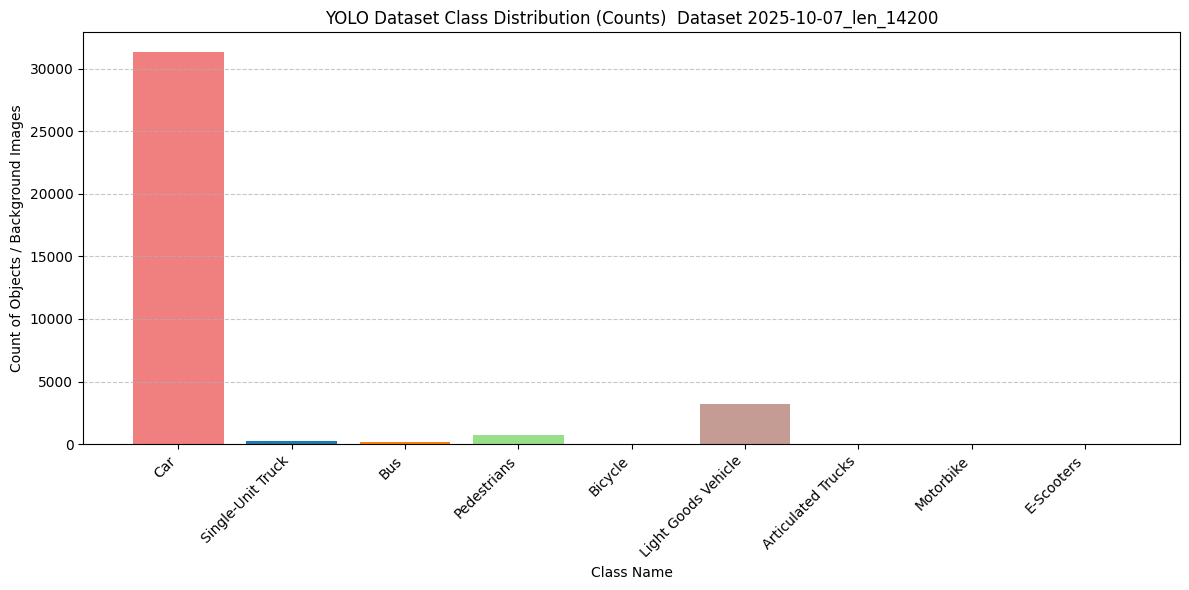

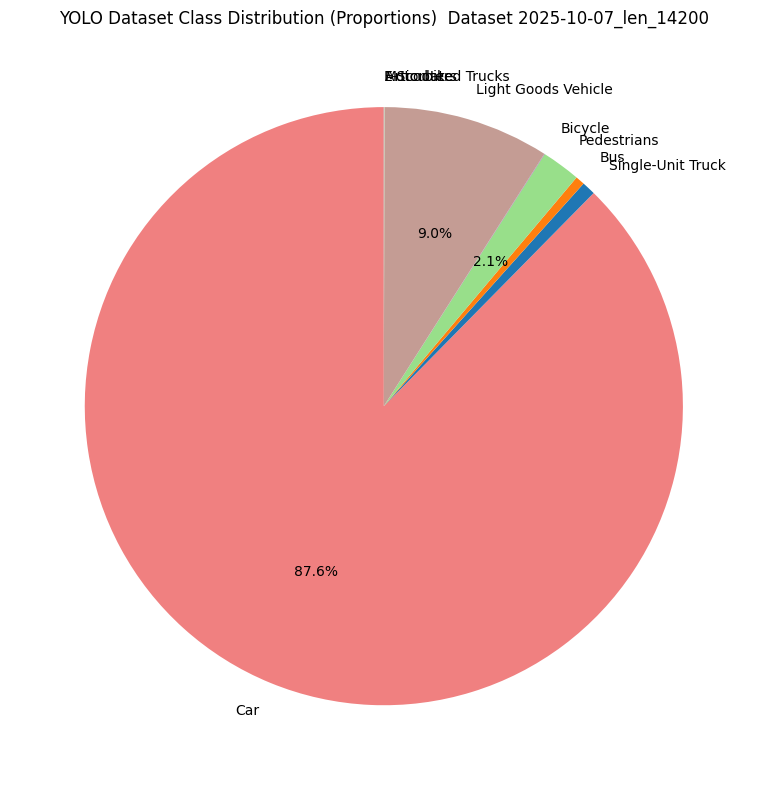


✅ Charts displayed.


In [1]:
import yaml
import os
import shutil
from collections import Counter
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt 
import numpy as np


def analyze_yolo_dataset(yaml_path: str) -> dict:
    """
    Analyzes a YOLO dataset specified by the data.yaml file to count
    the distribution of objects for each class across all splits, 
    including a count of images with no annotations (Background Images).

    This version handles datasets where 'train', 'val', and 'test' point 
    to text files containing lists of image paths, relative to the 'path' key.

    Args:
        yaml_path: The file path to the YOLO data.yaml configuration file.
    """
    # 1. Load the YAML configuration file
    try:
        with open(yaml_path, 'r') as f:
            data = yaml.safe_load(f)
    except FileNotFoundError:
        print(f"\n❌ Error: data.yaml file not found at '{yaml_path}'")
        return
    except Exception as e:
        print(f"\n❌ Error reading YAML file: {e}")
        return

    # Extract paths and class information
    base_dir = os.path.dirname(yaml_path)
    dataset_root = data.get('path', '')
    train_list_file = data.get('train', '')
    val_list_file = data.get('val', '')
    test_list_file = data.get('test', '')
    class_names = data.get('names', {}) # Expecting dict for class names
    num_classes = data.get('nc', 0)

    if not class_names or not num_classes:
        print("\n❌ Error: 'names' or 'nc' fields missing from data.yaml.")
        return

    print(f"\n--- YOLO Dataset Analyzer ---")
    print(f"Dataset Root: {dataset_root}")
    print(f"Number of Classes (nc): {num_classes}")
    print(f"Class Map: {class_names}")
    print("-" * 35)

    # Dictionary to hold the combined results: {class_id: count}. 
    # We will use class_id = -1 to store the count of background images.
    global_distribution = Counter()

    # 2. Define a helper function for processing a directory
    def process_list_file(label_dir_key: str, list_file_name: str, dataset_root: str) -> Counter:
        """Reads image list file, derives label paths, and returns class counts."""
        if not list_file_name:
            return Counter()

        list_file_path = os.path.join(base_dir, list_file_name)
        counts = Counter()
        total_images_processed = 0
        
        if not os.path.isfile(list_file_path):
            print(f"⚠️ Warning: {label_dir_key} list file not found: {list_file_path}")
            return counts
            
        print(f"\nProcessing {label_dir_key} list file: {list_file_path}")

        try:
            with open(list_file_path, 'r') as f:
                image_paths = [line.strip() for line in f if line.strip()]
        except Exception as e:
            print(f"Error reading list file {list_file_path}: {e}")
            return counts

        for image_path in image_paths:
            total_images_processed += 1
            
            # Full path to the image, which includes the 'images' directory
            full_image_path_rel_root = os.path.join(dataset_root, image_path)
            
            # 1. Get the directory name (e.g., 'path/to/train/images')
            label_dir = os.path.dirname(full_image_path_rel_root)
            # 2. Change the final directory 'images' to 'labels'
            if os.path.basename(label_dir) == 'images':
                label_dir = os.path.join(os.path.dirname(label_dir), 'labels')
            
            # 3. Get the filename base (e.g., 'image_001')
            image_filename = os.path.basename(image_path)
            label_file_base = os.path.splitext(image_filename)[0]
            
            # 4. Construct the full label file path relative to base_dir
            # (base_dir is the directory containing data.yaml)
            label_file_path = os.path.join(base_dir, label_dir.split(os.path.sep)[-2], "labels", label_file_base + '.txt')           
            objects_in_image_count = 0
            
            try:
                with open(label_file_path, 'r') as f:
                    for line in f:
                        # Class ID is the first token in the line (e.g., '5 0.4410...')
                        class_id_str = line.strip().split(' ')[0]
                        if class_id_str.isdigit():
                            class_id = int(class_id_str)
                            # Only count objects that belong to one of the defined classes (0 to nc-1)
                            if 0 <= class_id < num_classes:
                                counts[class_id] += 1
                                objects_in_image_count += 1
                            else:
                                print(f"Warning: Found out-of-range class ID {class_id} in {label_file_path}")
                
            except FileNotFoundError:
                # File not found means 0 annotated objects
                pass 
            except Exception as e:
                # Print the error for other file reading issues
                print(f"Error reading derived label file {label_file_path}: {e}")

            # If the image was processed but yielded no objects (empty or non-existent label file)
            if objects_in_image_count == 0:
                 counts[-1] += 1 # Use -1 to count background images

        # Calculate total objects found (excluding background count)
        total_objects_in_split = sum(v for k, v in counts.items() if k != -1)
        print(f"Total images processed: {total_images_processed}, Total objects found: {total_objects_in_split} (Excluding backgrounds)")
        return counts

    # 3. Process Train, Val, and Test datasets
    
    train_counts = process_list_file("Train", train_list_file, dataset_root)
    global_distribution.update(train_counts)

    val_counts = process_list_file("Validation", val_list_file, dataset_root)
    global_distribution.update(val_counts)
    
    test_counts = process_list_file("Test", test_list_file, dataset_root)
    global_distribution.update(test_counts)

    # 4. Generate and print the final distribution report
    
    total_background_images = global_distribution.pop(-1, 0)
    total_annotated_objects = sum(global_distribution.values())
    total_items_in_distribution = total_annotated_objects + total_background_images
    
    if total_items_in_distribution == 0:
        print("\n✅ Analysis Complete: No data found for analysis.")
        return
        
    print("\n" + "=" * 50)
    print("      FINAL CLASS DISTRIBUTION REPORT")
    print("=" * 50)
    
    # Format the header
    print(f"{'Class ID':<10} | {'Class Name':<20} | {'Count':<10} | {'Percentage':<10}")
    print("-" * 50)

    # Print Background Images count first
    background_percentage = (total_background_images / total_items_in_distribution) * 100
    print(f"{'--':<10} | {'Background Images':<20} | {total_background_images:<10} | {background_percentage:.2f}%")
    print("-" * 50)

    # Print annotated objects, sorted by Class ID
    for class_id in sorted(global_distribution.keys()):
        count = global_distribution[class_id]
        
        # Ensure class_id is within the defined range and handle dict lookup
        # Note: class_names is expected to be a dictionary {id: name}
        # In a typical YOLO file, 'names' is a list/tuple, but the original code expects a dict/list for lookup.
        # Assuming class_names is a list/tuple where index is the class_id:
        try:
             name = class_names[class_id]
        except (TypeError, IndexError):
             # Fallback if class_names is not a list or class_id is out of bounds
             name = f"UNKNOWN CLASS ID {class_id}"
            
        percentage = (count / total_items_in_distribution) * 100
        
        print(f"{class_id:<10} | {name:<20} | {count:<10} | {percentage:.2f}%")

    print("-" * 50)
    print(f"{'TOTAL:':<32} | {total_items_in_distribution:<10} | {'100.00%':<10}")
    print("=" * 50)
    return global_distribution, total_items_in_distribution, class_names

def generate_yolo_charts(plot_data: List[Tuple[str, int, float]], title_suffix: str = "") -> None:
    """
    Generates and displays Bar and Pie charts for the YOLO dataset distribution.

    Args:
        plot_data: A list of tuples containing (Class Name, Count, Percentage) for 
                   all classes and the background images.
        title_suffix: A string to append to the chart titles (e.g., dataset name).
    """
    if not plot_data:
        print("No data available to generate charts.")
        return

    chart_labels = [item[0] for item in plot_data]
    chart_counts = [item[1] for item in plot_data]

    # --- Bar Chart ---
    plt.figure(figsize=(12, 6))
    
    # Generate colors, using a distinct color for Background Images (the first item)
    colors = ['lightcoral'] + plt.cm.get_cmap('tab20', len(chart_labels) - 1).colors.tolist()
    
    plt.bar(chart_labels, chart_counts, color=colors)
    plt.title(f'YOLO Dataset Class Distribution (Counts) {title_suffix}')
    plt.xlabel('Class Name')
    plt.ylabel('Count of Objects / Background Images')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show(block=False) # Show the first plot without blocking

    # --- Pie Chart ---
    plt.figure(figsize=(8, 8))

    # Function to format the percentage display
    def autopct_format(pct):
        return ('%.1f%%' % pct) if pct >= 1 else ''

    plt.pie(
        chart_counts,
        labels=chart_labels,
        autopct=autopct_format,
        startangle=90,
        colors=colors,
        textprops={'fontsize': 10}
    )
    plt.title(f'YOLO Dataset Class Distribution (Proportions) {title_suffix}')
    plt.tight_layout()
    plt.show() # Show the final plot (blocks until closed)
    
    print("\n✅ Charts displayed.")

    
# check if the path is correct
yaml_path = r"yolo_dataset\2025-10-07_len_14200\data.yaml"
if os.path.exists(yaml_path):
    print(f"\n✅ Found data.yaml at: {yaml_path}")
    global_distribution, total_items_in_distribution, class_names = analyze_yolo_dataset(yaml_path)
    generate_yolo_charts([(class_names[class_id], count, (count / total_items_in_distribution) * 100) for class_id, count in global_distribution.items()], title_suffix=" Dataset 2025-10-07_len_14200")
else:
    print(f"\n❌ data.yaml not found at: {yaml_path}. Skipping analysis execution.")


In [19]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------------- -------------- 5.2/8.1 MB 28.0 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 22.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
